In [37]:
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
r = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 1", skiprows=3)

In [39]:
r2 = r.iloc[0:31, [0,2,4]].copy()

r2.rename(
    columns={
        "Computational Time (sec).1": "posix_comp_time",
        "Computational Time (sec).2": "openmp_comp_time",},
    inplace=True)

r2

,n,posix_comp_time,openmp_comp_time
0,10000000,0.664019,0.39406
1,11000000,0.760851,0.444861
2,12000000,0.847935,0.503745
3,13000000,0.93635,0.56334
4,14000000,1.072575,0.64324
5,15000000,1.16066,0.714647
6,16000000,1.268275,0.763139
7,17000000,1.379663,0.838065
8,18000000,1.566074,0.916491
9,19000000,1.63604,0.969385


In [40]:
r3 = r.iloc[35:66, [0,2,4]].copy()

r3.rename(
    columns={
        "Computational Time (sec).1": "posix_comp_time",
        "Computational Time (sec).2": "openmp_comp_time",},
    inplace=True)

r3

,n,posix_comp_time,openmp_comp_time
35,10000000,0.199615,0.1765
36,11000000,0.208622,0.144777
37,12000000,0.230629,0.140874
38,13000000,0.268316,0.151469
39,14000000,0.29424,0.166132
40,15000000,0.319859,0.183388
41,16000000,0.374307,0.199738
42,17000000,0.412031,0.221701
43,18000000,0.392722,0.237606
44,19000000,0.411162,0.259808


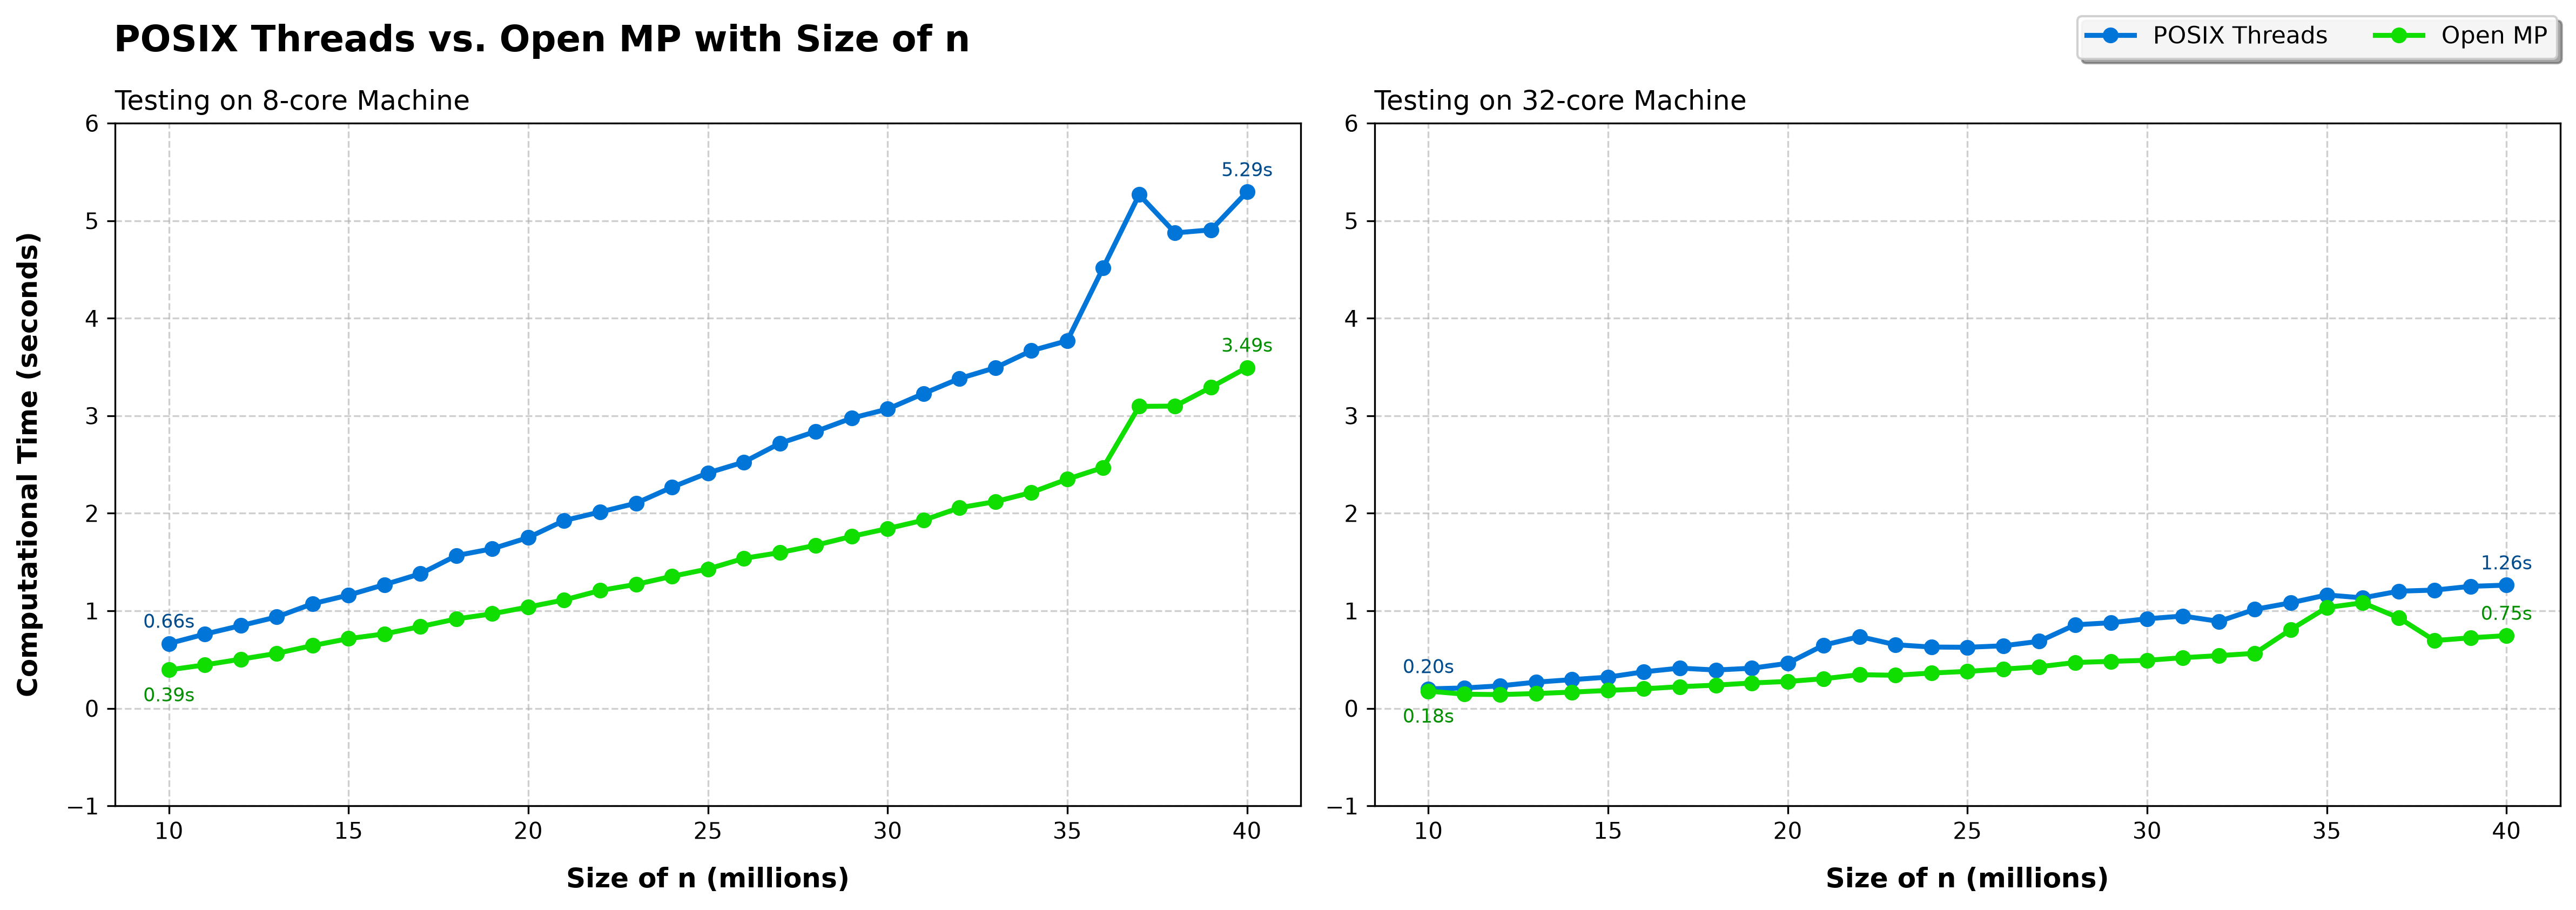

In [41]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)


# =========================
# 8-core graph
# =========================
ax = axes[0]

line1, = ax.plot(
    r2.n, r2.posix_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color='#0275D8', label='Serial Code'
)

line2, = ax.plot(
    r2.n, r2.openmp_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color="#0FDE00", label='Open MP'
)

ax.set_title(
    "Testing on 8-core Machine",
    fontsize=12,
    loc='left'
)

ax.set_xlabel(
    "Size of n (millions)",
    fontsize=12,
    fontweight='semibold',
    labelpad=10
)

ax.set_ylabel(
    "Computational Time (seconds)",
    fontsize=12,
    fontweight='semibold',
    labelpad=10
)

# X-axis: show ticks/grid every 5 million
ax.xaxis.set_major_locator(MultipleLocator(5_000_000))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:g}")
)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1, 6)


# Annotations
ax.annotate(
    f"{r2.posix_comp_time.iloc[0]:.2f}s",
    (r2.n.iloc[0], r2.posix_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#014C8C'
)

ax.annotate(
    f"{r2.posix_comp_time.iloc[-1]:.2f}s",
    (r2.n.iloc[-1], r2.posix_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#014C8C'
)

ax.annotate(
    f"{r2.openmp_comp_time.iloc[0]:.2f}s",
    (r2.n.iloc[0], r2.openmp_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, -14),
    ha='center',
    fontsize=8.5,
    color="#058F03"
)

ax.annotate(
    f"{r2.openmp_comp_time.iloc[-1]:.2f}s",
    (r2.n.iloc[-1], r2.openmp_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color="#058F03"
)


# =========================
# 32-core graph
# =========================
ax = axes[1]

ax.plot(
    r3.n, r3.posix_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color='#0275D8', label='Serial Code'
)

ax.plot(
    r3.n, r3.openmp_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color="#0FDE00", label='Open MP'
)

ax.set_title(
    "Testing on 32-core Machine",
    fontsize=12,
    loc='left'
)

ax.set_xlabel(
    "Size of n (millions)",
    fontsize=12,
    fontweight='semibold',
    labelpad=10
)

# X-axis: show ticks/grid every 5 million
ax.xaxis.set_major_locator(MultipleLocator(5_000_000))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:g}")
)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1, 6)


# Annotations
ax.annotate(
    f"{r3.posix_comp_time.iloc[0]:.2f}s",
    (r3.n.iloc[0], r3.posix_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#014C8C'
)

ax.annotate(
    f"{r3.posix_comp_time.iloc[-1]:.2f}s",
    (r3.n.iloc[-1], r3.posix_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#014C8C'
)

ax.annotate(
    f"{r3.openmp_comp_time.iloc[0]:.2f}s",
    (r3.n.iloc[0], r3.openmp_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, -14),
    ha='center',
    fontsize=8.5,
    color="#058F03"
)

ax.annotate(
    f"{r3.openmp_comp_time.iloc[-1]:.2f}s",
    (r3.n.iloc[-1], r3.openmp_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color="#058F03"
)


# =========================
# Overall title
# =========================
fig.suptitle(
    "POSIX Threads vs. Open MP with Size of n",
    fontsize=16,
    fontweight='bold',
    x=0.047,
    y=0.92,
    ha='left'
)


# =========================
# Overall legend
# =========================
fig.legend(
    handles=[line1, line2],
    labels=['POSIX Threads', 'Open MP'],
    loc='upper right',
    bbox_to_anchor=(0.994, 0.94),
    ncol=2,
    fontsize=10.5,
    frameon=True,
    framealpha=0.9,
    shadow=True
)


# =========================
# Layout & save
# =========================
plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig("task3_graph3.png", dpi=300, bbox_inches='tight')

plt.show()